In [143]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [144]:
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target=[1]*35+[0]*14

In [145]:
train_input = fish_data[:35]
train_target = fish_target[:35]

test_input = fish_data[35:]
test_target = fish_target[35:]

In [146]:
import numpy as np

input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

In [147]:
np.random.seed(42)
index = np.arange(49)
np.random.shuffle(index)

In [148]:
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

In [149]:
test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

In [150]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [151]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [152]:
import numpy as np
fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [153]:
train_input_7, test_input_7, train_target_7, test_target_7 = train_test_split(fish_data, fish_target,test_size=0.3, stratify=fish_target, random_state=42)

In [154]:
train_input_5, test_input_5, train_target_5, test_target_5 = train_test_split(fish_data, fish_target,test_size=0.5, stratify=fish_target, random_state=42)

In [155]:
train_input_9, test_input_9, train_target_9, test_target_9 = train_test_split(fish_data, fish_target,test_size=0.1, stratify=fish_target, random_state=42)

In [156]:
kn = KNeighborsClassifier()
kn.fit(train_input_7, train_target_7)
print(kn.score(test_input_7, test_target_7))

1.0


In [157]:
print(f"훈련 세트: {len(train_input_7)}, 테스트 세트: {len(test_input_7)}")

훈련 세트: 34, 테스트 세트: 15


In [158]:
kn.fit(train_input_5, train_target_5)
print(kn.score(test_input_5, test_target_5))

1.0


In [159]:
print(f"훈련 세트: {len(train_input_5)}, 테스트 세트: {len(test_input_5)}")

훈련 세트: 24, 테스트 세트: 25


In [160]:
kn.fit(train_input_9, train_target_9)
print(kn.score(test_input_9, test_target_9))

1.0


In [161]:
print(f"훈련 세트: {len(train_input_9)}, 테스트 세트: {len(test_input_9)}")

훈련 세트: 44, 테스트 세트: 5


In [162]:
lengths = [fish[0] for fish in train_input_7]
weights = [fish[1] for fish in train_input_7]
n = len(train_input)

In [163]:
mean_length = sum(lengths) / n
mean_weight = sum(weights)/ n

In [164]:
var_length = sum([(x - mean_length)**2 for x in lengths]) / n
var_weight = sum([(x - mean_weight)**2 for x in weights]) / n

In [165]:
std_length = var_length ** 0.5
std_weight = var_weight ** 0.5

In [166]:
train_scaled_manual = []
for fish in train_input_7:
    scaled_l = (fish[0] - mean_length) / std_length
    scaled_w = (fish[1] - mean_weight) / std_weight
    train_scaled_manual.append([scaled_l, scaled_w])

In [167]:
print(f"수동 계산 평균: {mean_length:.2f}, {mean_weight:.2f}")
print(f"수동 계산 표준편차: {std_length:.2f}, {std_weight:.2f}")
print(f"스케일링된 첫 데이터: {train_scaled_manual[0]}")

수동 계산 평균: 26.25, 432.87
수동 계산 표준편차: 9.97, 314.87
스케일링된 첫 데이터: [np.float64(-1.4099874517042164), np.float64(-1.3360240506649432)]


In [168]:
import matplotlib.pyplot as plt

In [169]:
scaled_lengths = [fish[0] for fish in train_scaled_manual]
scaled_weights = [fish[1] for fish in train_scaled_manual]

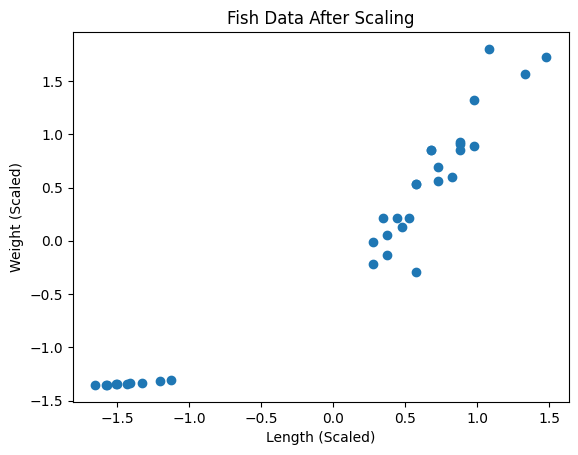

In [172]:
plt.scatter(scaled_lengths, scaled_weights)
plt.xlabel('Length (Scaled)')
plt.ylabel('Weight (Scaled)')
plt.title('Fish Data After Scaling')
plt.show()